# House Price Predictor

Implemented from scratch using NumPy.

Features:
- Multiple Linear Regression
- Mean Normalization
- Gradient Descent
- Cost Function
- Prediction
- Comparison with Scikit-Learn

Final MAE:
My Model: 12010.56
Scikit-Learn: 12012.21

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import pandas as pd

%matplotlib inline

In [19]:
#Extracting the data from the csv file to our variables :- X is an array containing all the features and Y containing targets


# data = pd.read_csv(r"C:\Users\vatsh\Downloads\house-prices.csv")
data=pd.read_csv("house-prices-Data.csv")
data = data.to_numpy()

X = data[:, :-1]   # All features
Y = data[:, -1]    # Last column (price)

print(X.shape)
print(Y.shape)

print(X[:5])
print(Y[:5])


(128, 4)
(128,)
[[1790    2    2    2]
 [2030    4    2    3]
 [1740    3    2    1]
 [1980    3    2    3]
 [2130    3    3    3]]
[114300 114200 114800  94700 119800]


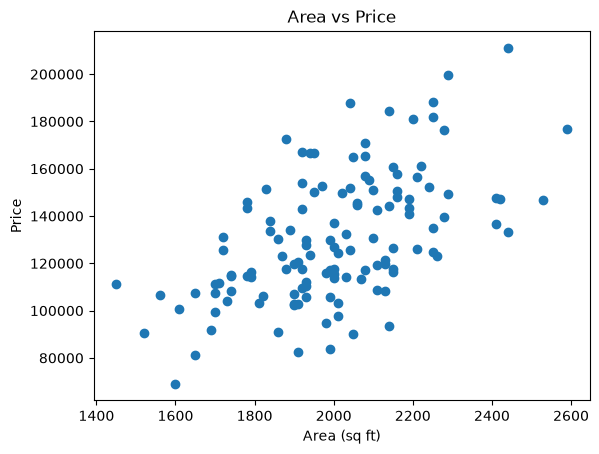

In [4]:
# AREA v/s Price graph 

plt.scatter(X[:,0],Y)

plt.title("Area vs Price")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price")

plt.show()

In [ ]:
# Mean normalising the data because one of the feature is too big as compared to other features which can create various problems 


m=X.shape[0]
n=X.shape[1]
X_sum = 0


for i in range(m):
    X_sum += X[i]

X_mean = X_sum/m

print(X_mean)

X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)

norm_X = (X-X_mean)/(X_max-X_min)

print(norm_X [:5])


def compute_normaliseddata(X):
    norm_X=(X-X_mean)/(X_max-X_min)

    return norm_X


[2000.9375       3.0234375    2.4453125    2.578125 ]
[[-0.18503289 -0.34114583 -0.22265625 -0.115625  ]
 [ 0.02549342  0.32552083 -0.22265625  0.084375  ]
 [-0.22889254 -0.0078125  -0.22265625 -0.315625  ]
 [-0.01836623 -0.0078125  -0.22265625  0.084375  ]
 [ 0.11321272 -0.0078125   0.27734375  0.084375  ]]


In [10]:
W=np.array([2,1,4,0.1])
B=  23

In [6]:
# Cost function for our model 


# f_x= np.dot(norm_X,W)+B
# W=np.array([1,3,4,5])
# B=12
# f_x= np.dot(norm_X,W)+B


def Cost_function(X,Y,W,B):
        m=X.shape[0]
        
        cst_fn=0
        for i in range(m):
            f_x= np.dot(X[i],W)+B
            cst_fn += (f_x - Y[i])**2
        cst_fn  = (1/(2*m))*cst_fn  
        return cst_fn 


In [20]:
# Calculating Gradient which will be used in our gradient desscent model 

def grad_cal(X,Y,W,B):
    
    m,n=X.shape
    dfx_dw=np.zeros(n)
    dfx_db=0

    for i in range(m):
        f_x= np.dot(X[i],W)+B
        dfx_db += (f_x-Y[i])
        for j in range(n):
                dfx_dw[j] +=(f_x-Y[i])*X[i,j]
    dfx_db= dfx_db*(1/m)
    dfx_dw= dfx_dw*(1/m)

    
    return dfx_dw,dfx_db 

alpha=0.01

grad1,grad2=grad_cal(norm_X,Y,W,B)
print(grad1,grad2)


[-2735.75214362 -3392.55090872 -3588.10444559  1788.22995998] -130404.34375000001


In [14]:
# Our Gradient Descent model which will be used to find the optimal values of weights and bias to minimise our cost function to get a accurate model for prediction 

def gradient_descent(alpha,X,Y,W,B,itrations):
    j_history=[]
    for itr in range(itrations):
        dfx_dw,dfx_db=grad_cal(X,Y,W,B)

        W = W - alpha*dfx_dw
        B = B - alpha*dfx_db

        cost= Cost_function(X,Y,W,B)
        j_history.append(cost)


        if (itr%1000)==0:
            print("Itration no: ",itr, "cost is :",j_history[-1])

    return W,B,j_history
    

In [15]:
# Calling the Gradient descent function we just made to train the model 

W=np.array([2,1,4,0.1])
B=  23
alpha = 0.01
itrations=30000



new_w,new_b,j_history=gradient_descent(alpha,norm_X,Y,W,B,itrations)
    

Itration no:  0 cost is : 8691215596.239887
Itration no:  1000 cost is : 187354539.71060604
Itration no:  2000 cost is : 144967231.61528406
Itration no:  3000 cost is : 128830665.48555493
Itration no:  4000 cost is : 120931684.0469173
Itration no:  5000 cost is : 116515716.4548089
Itration no:  6000 cost is : 113828118.14898762
Itration no:  7000 cost is : 112090972.41876577
Itration no:  8000 cost is : 110920427.51510102
Itration no:  9000 cost is : 110109917.79952364
Itration no:  10000 cost is : 109539113.84655432
Itration no:  11000 cost is : 109133001.04919764
Itration no:  12000 cost is : 108842318.57991803
Itration no:  13000 cost is : 108633527.52931295
Itration no:  14000 cost is : 108483253.5695687
Itration no:  15000 cost is : 108374970.34124656
Itration no:  16000 cost is : 108296892.31314795
Itration no:  17000 cost is : 108240572.29628623
Itration no:  18000 cost is : 108199938.0747325
Itration no:  19000 cost is : 108170617.2879933
Itration no:  20000 cost is : 108149458

In [23]:
# Calculating Mean Absolute error of my model and then comparing it with M.A.E of scikit learn model


mae = np.mean(np.abs(pred - Y))

print(" My Model's Mean Absolute Error is :",mae)


from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(norm_X, Y)

pred = model.predict(norm_X)

mae_scikit = np.mean(np.abs(pred - Y))
print(f" Scikit's M.A.E(mean absolut error) is:{mae_scikit}")

 My Model's Mean Absolute Error is : 12010.564470185804
 Scikit's M.A.E(mean absolut error) is:12012.216493085347


In [16]:
# Comparing our Model's prediction with the actual Target values 

pred = np.dot(norm_X,new_w)+new_b

for i in range(10):
    print("Actual:",Y[i],
          "Predicted:",pred[i])

Actual: 114300 Predicted: 110068.86172715305
Actual: 114200 Predicted: 129968.40262516348
Actual: 114800 Predicted: 129931.65612177318
Actual: 94700 Predicted: 117533.55983855238
Actual: 119800 Predicted: 139464.90076717065
Actual: 114600 Predicted: 118816.99411456825
Actual: 151600 Predicted: 121031.34877119119
Actual: 150700 Predicted: 151528.74409675677
Actual: 119200 Predicted: 134884.016490758
Actual: 104000 Predicted: 114886.83143919802


In [17]:
# Comparing our trained model's weights and bias with the weights and bias found using scikit library functions 

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(norm_X, Y)

print("Your W:", new_w)
print("Your b:", new_b)

print("Sklearn W:", model.coef_)
print("Sklearn b:", model.intercept_)

Your W: [ 70047.49758472  28087.75236184  25429.12986126 -67862.34470001]
Your b: 130427.34374999929
Sklearn W: [ 70497.53855441  27959.25780618  25292.6949728  -68005.05706143]
Sklearn b: 130427.34375


In [18]:
# Our model is complety ready to predict the preice of any house so asking deatils of the house and giving the price of the house 


input_area=float(input("Enter the Ares in square ft pf your house :"))
input_bedrooms=float(input("Enter the no of bedrooms in your house :"))
input_bathrooms=float(input("Enter the no of bathrooms in your house :"))
input_offer=float(input("Enter the no of offers for your house :"))

input_x = np.array([input_area,input_bedrooms,input_bathrooms,input_offer])

input_norm_X = compute_normaliseddata(input_x)
print(input_x)
print(input_norm_X)


prediction= np.dot(input_norm_X,new_w)+new_b


print(f"\n🏠 Predicted House Price: ${prediction:,.2f}")

    
    

[1.25e+03 4.00e+00 3.00e+00 1.00e+00]
[-0.65871711  0.32552083  0.27734375 -0.315625  ]

🏠 Predicted House Price: $121,900.67
